# Canadian Retail Sales Analysis
## Business Goals & KPI Dashboard
**Data Source:** Statistics Canada — Monthly Retail Trade Survey (2017–2026)

### Goals Covered
1. Monitor Retail Industry Performance
2. Analyze Geographic Performance
3. Understand Seasonality
4. Measure E-Commerce Growth
5. Improve Forecasting & Planning

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_theme(style='whitegrid')

pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
print("Libraries loaded!")

Libraries loaded!


## Data Loading
Choose **one** of the two options below and run that cell.

In [2]:
# Load dataset
df = pd.read_csv(
    "Dataset/retail_sales_cleaned.csv",
    parse_dates=['REF_DATE']
)

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

df.head()

Loaded: 66,494 rows x 12 columns


,REF_DATE,Year,Month,Month_Name,Quarter,GEO,Geo_Level,Industry,Sales,Adjustments,VALUE,Sales_Actual
0,2017-01-01,2017,1,January,1,Canada,National,Retail trade,Total retail sales,Unadjusted,41377009,41377009000
1,2017-01-01,2017,1,January,1,Canada,National,Retail trade,Total retail sales,Seasonally adjusted,50417235,50417235000
2,2017-01-01,2017,1,January,1,Canada,National,Retail trade,Retail e-commerce sales,Unadjusted,1110045,1110045000
3,2017-01-01,2017,1,January,1,Canada,National,Retail trade,Retail e-commerce sales,Seasonally adjusted,1236885,1236885000
4,2017-01-01,2017,1,January,1,Canada,National,Motor vehicle and parts dealers,Total retail sales,Unadjusted,10162441,10162441000


## Data Overview

In [3]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Date Range  : {df['REF_DATE'].min().strftime('%B %Y')} -> {df['REF_DATE'].max().strftime('%B %Y')}")
print(f"Total Rows  : {len(df):,}")
print(f"Geo Levels  : {df['Geo_Level'].unique().tolist()}")
print(f"Industries  : {df['Industry'].nunique()}")
print(f"Sales Types : {df['Sales'].unique().tolist()}")
print(f"Adjustments : {df['Adjustments'].unique().tolist()}")
print()
display(df.describe())

DATASET OVERVIEW
Date Range  : January 2017 -> February 2026
Total Rows  : 66,494
Geo Levels  : ['National', 'Province', 'City', 'Territory']
Industries  : 30
Sales Types : ['Total retail sales', 'Retail e-commerce sales']
Adjustments : ['Unadjusted', 'Seasonally adjusted']



,REF_DATE,Year,Month,Quarter,VALUE,Sales_Actual
count,66494,"66,494","66,494","66,494","66,494","66,494"
mean,2021-10-30 05:18:55.753602304,"2,021",6,2,"1,198,721","1,198,721,394"
min,2017-01-01 00:00:00,"2,017",1,1,1,"1,000"
25%,2019-09-01 00:00:00,"2,019",3,1,"37,812","37,811,750"
50%,2021-12-01 00:00:00,"2,021",6,2,"164,909","164,909,000"
75%,2024-01-01 00:00:00,"2,024",9,3,"676,897","676,896,750"
max,2026-02-01 00:00:00,"2,026",12,4,"76,831,848","76,831,848,000"
std,NaN,3,3,1,"4,291,667","4,291,666,946"


## Prepare Filtered Datasets

In [4]:
# National unadjusted total retail sales (aggregate)
national_unadj = df[
    (df['GEO'] == 'Canada') &
    (df['Industry'] == 'Retail trade') &
    (df['Sales'] == 'Total retail sales') &
    (df['Adjustments'] == 'Unadjusted')
].copy().sort_values('REF_DATE').reset_index(drop=True)

# National seasonally adjusted
national_sadj = df[
    (df['GEO'] == 'Canada') &
    (df['Industry'] == 'Retail trade') &
    (df['Sales'] == 'Total retail sales') &
    (df['Adjustments'] == 'Seasonally adjusted')
].copy().sort_values('REF_DATE').reset_index(drop=True)

# Top-level industry breakdown (no sub-categories to avoid double counting)
top_level_industries = [
    'Motor vehicle and parts dealers',
    'Building material and garden equipment and supplies dealers',
    'Food and beverage retailers',
    'Furniture, home furnishings, electronics and appliances retailers',
    'General merchandise retailers',
    'Health and personal care retailers',
    'Gasoline stations and fuel vendors',
    'Clothing, clothing accessories, shoes, jewellery, luggage and leather goods retailers',
    'Sporting goods, hobby, musical instrument, book, and miscellaneous retailers',
    'Cannabis retailers'
]

industry_df = df[
    (df['GEO'] == 'Canada') &
    (df['Industry'].isin(top_level_industries)) &
    (df['Sales'] == 'Total retail sales') &
    (df['Adjustments'] == 'Unadjusted')
].copy()

# Province-level data
province_df = df[
    (df['Geo_Level'] == 'Province') &
    (df['Industry'] == 'Retail trade') &
    (df['Sales'] == 'Total retail sales') &
    (df['Adjustments'] == 'Unadjusted')
].copy()

# E-commerce
ecomm_df = df[
    (df['GEO'] == 'Canada') &
    (df['Industry'] == 'Retail trade') &
    (df['Sales'] == 'Retail e-commerce sales') &
    (df['Adjustments'] == 'Unadjusted')
].copy().sort_values('REF_DATE').reset_index(drop=True)

# Determine last full year (12 months present)
full_years = [
    y for y in national_unadj['Year'].unique()
    if national_unadj[national_unadj['Year'] == y]['Month'].nunique() == 12
]
analysis_year = max(full_years) if full_years else national_unadj['Year'].max()
first_year    = national_unadj['Year'].min()

# Short display names for industries
short_names = {
    'Motor vehicle and parts dealers': 'Motor Vehicle & Parts',
    'Building material and garden equipment and supplies dealers': 'Building Materials',
    'Food and beverage retailers': 'Food & Beverage',
    'Furniture, home furnishings, electronics and appliances retailers': 'Furniture & Electronics',
    'General merchandise retailers': 'General Merchandise',
    'Health and personal care retailers': 'Health & Personal Care',
    'Gasoline stations and fuel vendors': 'Gasoline Stations',
    'Clothing, clothing accessories, shoes, jewellery, luggage and leather goods retailers': 'Clothing & Accessories',
    'Sporting goods, hobby, musical instrument, book, and miscellaneous retailers': 'Sporting Goods & Misc',
    'Cannabis retailers': 'Cannabis'
}

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f"Analysis year (last full year): {analysis_year}")
print(f"First year: {first_year}")
print("Filters ready!")

Analysis year (last full year): 2025
First year: 2017
Filters ready!


---
## Section 1 — Sales KPIs
**KPIs:** Total Retail Sales | Monthly/Yearly Growth | Average Monthly Sales | Max & Min Sales Month

In [5]:
# ── KPI: Core Sales Statistics ────────────────────────────────────────────────
yearly_sales = national_unadj.groupby('Year')['Sales_Actual'].sum()
total_all_time = national_unadj['Sales_Actual'].sum()
avg_monthly    = national_unadj['Sales_Actual'].mean()
max_row        = national_unadj.loc[national_unadj['Sales_Actual'].idxmax()]
min_row        = national_unadj.loc[national_unadj['Sales_Actual'].idxmin()]

print("=" * 60)
print("SALES KPI SUMMARY")
print("=" * 60)
print(f"All-Time Total Retail Sales : ${total_all_time/1e12:.2f} Trillion CAD")
print(f"Average Monthly Sales       : ${avg_monthly/1e9:.2f} Billion")
print(f"Peak Sales Month            : {max_row['Month_Name']} {max_row['Year']}  —  ${max_row['Sales_Actual']/1e9:.2f}B")
print(f"Lowest Sales Month          : {min_row['Month_Name']} {min_row['Year']}  —  ${min_row['Sales_Actual']/1e9:.2f}B")
print()
print("Annual Totals:")
for yr, val in yearly_sales.items():
    print(f"  {yr} : ${val/1e9:.1f}B")

SALES KPI SUMMARY
All-Time Total Retail Sales : $79.71 Trillion CAD
Average Monthly Sales       : $724.62 Billion
Peak Sales Month            : May 2025  —  $903.23B
Lowest Sales Month          : April 2020  —  $448.49B

Annual Totals:
  2017 : $7.08T
  2018 : $7.36T
  2019 : $7.88T
  2020 : $7.81T
  2021 : $8.75T
  2022 : $9.37T
  2023 : $9.66T
  2024 : $9.94T
  2025 : $10.28T
  2026 : $1.58T


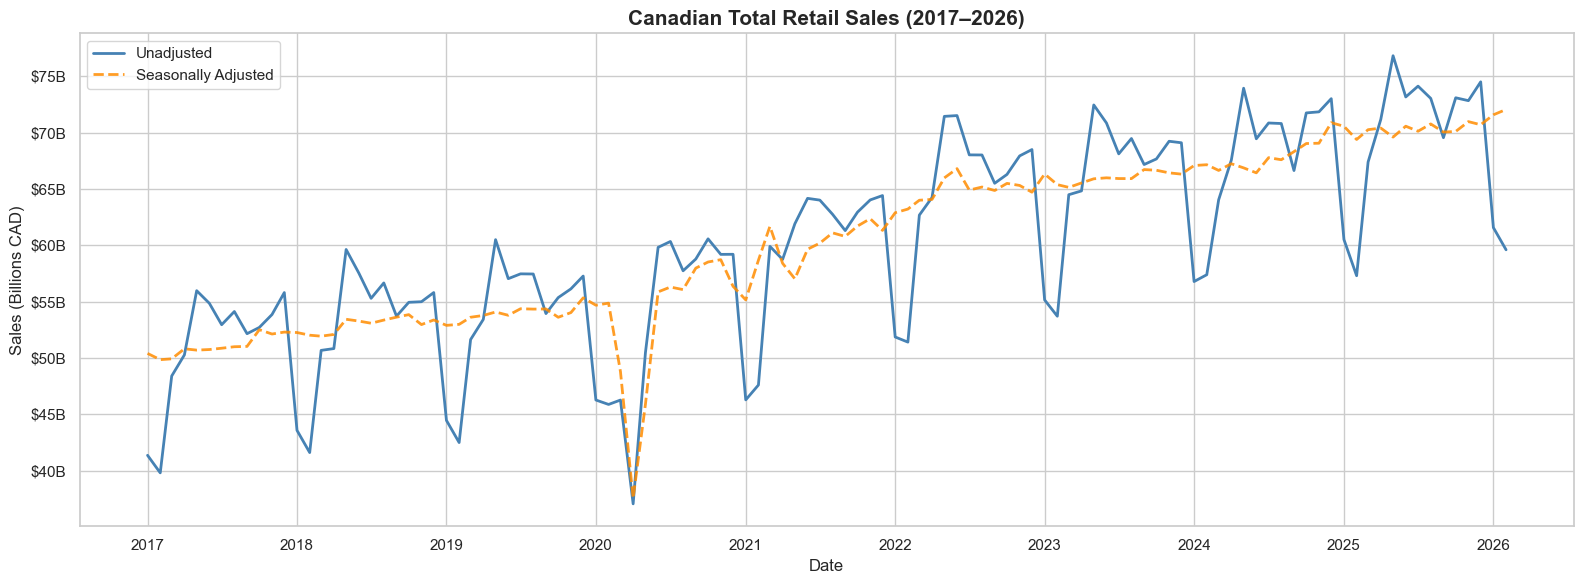

In [7]:
# ── KPI: Monthly Sales Trend ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(national_unadj['REF_DATE'], national_unadj['Sales_Actual']/1e9,
        color='steelblue', linewidth=2, label='Unadjusted')
ax.plot(national_sadj['REF_DATE'], national_sadj['Sales_Actual']/1e9,
        color='darkorange', linewidth=2, linestyle='--', alpha=0.85,
        label='Seasonally Adjusted')
ax.set_title('Canadian Total Retail Sales (2017–2026)', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (Billions CAD)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.legend(fontsize=11)
plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/01_monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

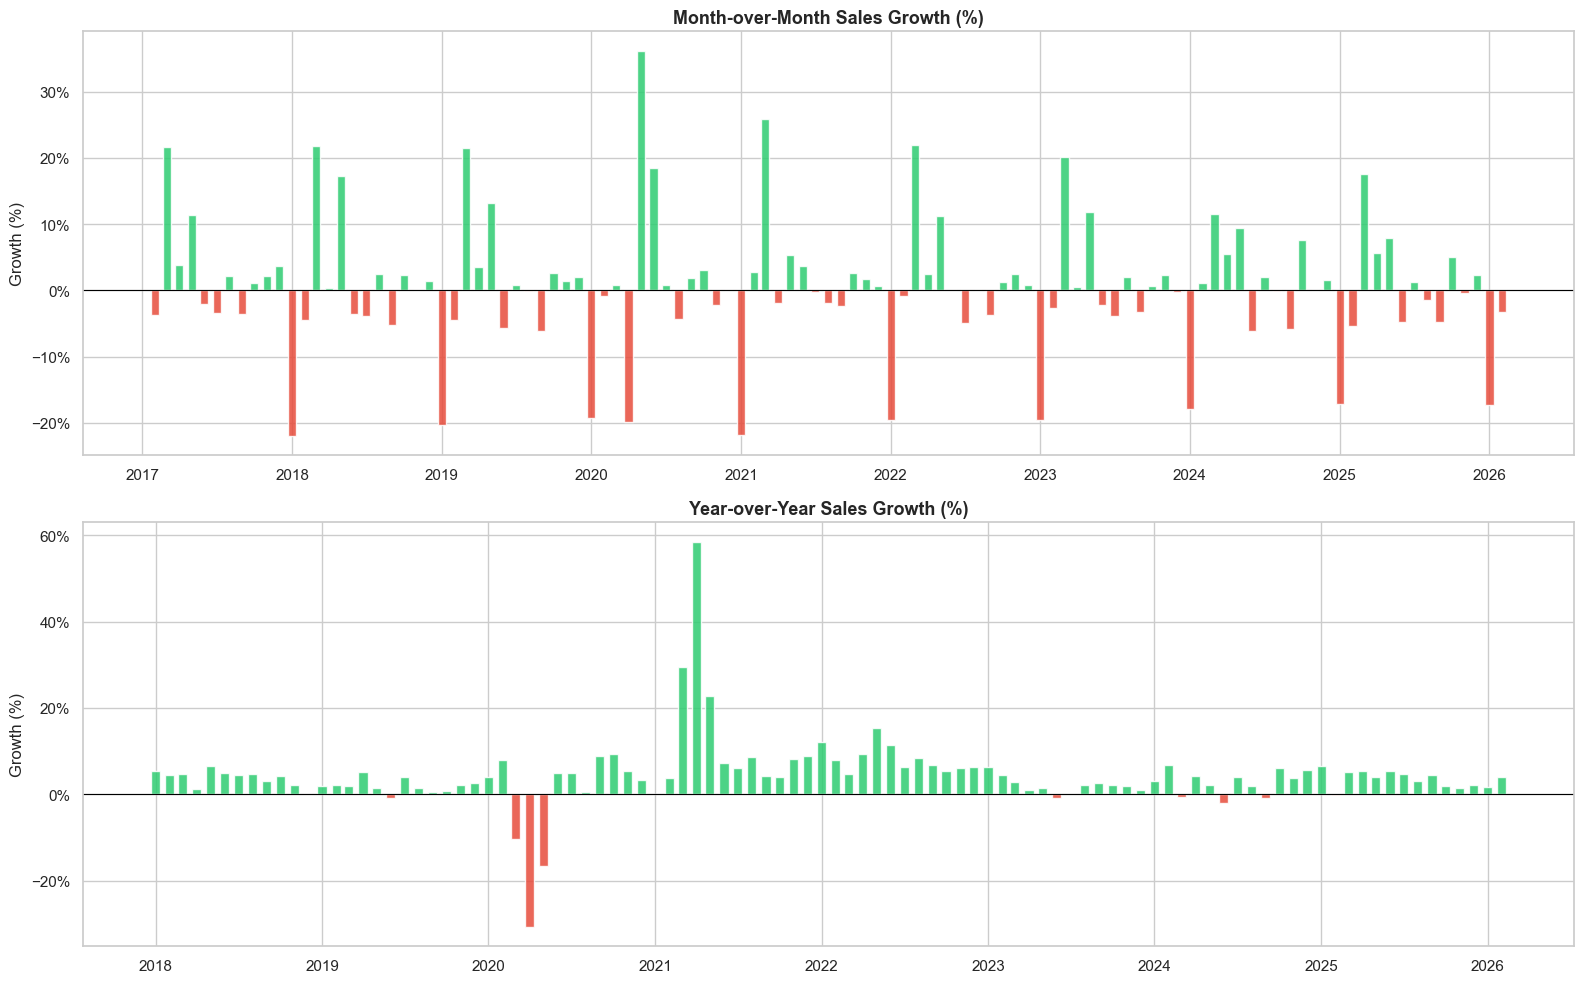

Average MoM Growth: 0.82%
Average YoY Growth: 4.39%


In [8]:
# ── KPI: Month-over-Month & Year-over-Year Growth ─────────────────────────────
# Bars use explicit width (20 days) so they are clearly visible on the date axis.
# Green = positive growth, Red = negative — zero-line added for reference.
national_unadj['MoM_Growth_pct'] = national_unadj['Sales_Actual'].pct_change() * 100
national_unadj['YoY_Growth_pct'] = national_unadj['Sales_Actual'].pct_change(12) * 100

import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
bar_width = 20  # days — wide enough to be clearly visible

for ax, col, title in zip(
    axes,
    ['MoM_Growth_pct', 'YoY_Growth_pct'],
    ['Month-over-Month Sales Growth (%)', 'Year-over-Year Sales Growth (%)']
):
    dates  = mdates.date2num(national_unadj['REF_DATE'])
    values = national_unadj[col].values
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in values]
    ax.bar(dates, values, width=bar_width, color=colors, alpha=0.85)
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Growth (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/02_mom_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()

avg_mom = national_unadj['MoM_Growth_pct'].mean()
avg_yoy = national_unadj['YoY_Growth_pct'].mean()
print(f"Average MoM Growth: {avg_mom:.2f}%")
print(f"Average YoY Growth: {avg_yoy:.2f}%")


---
## Section 2 — Industry KPIs
**KPIs:** Top Industry by Sales | Industry Growth Rate | Industry Market Share | Seasonal Industry Index

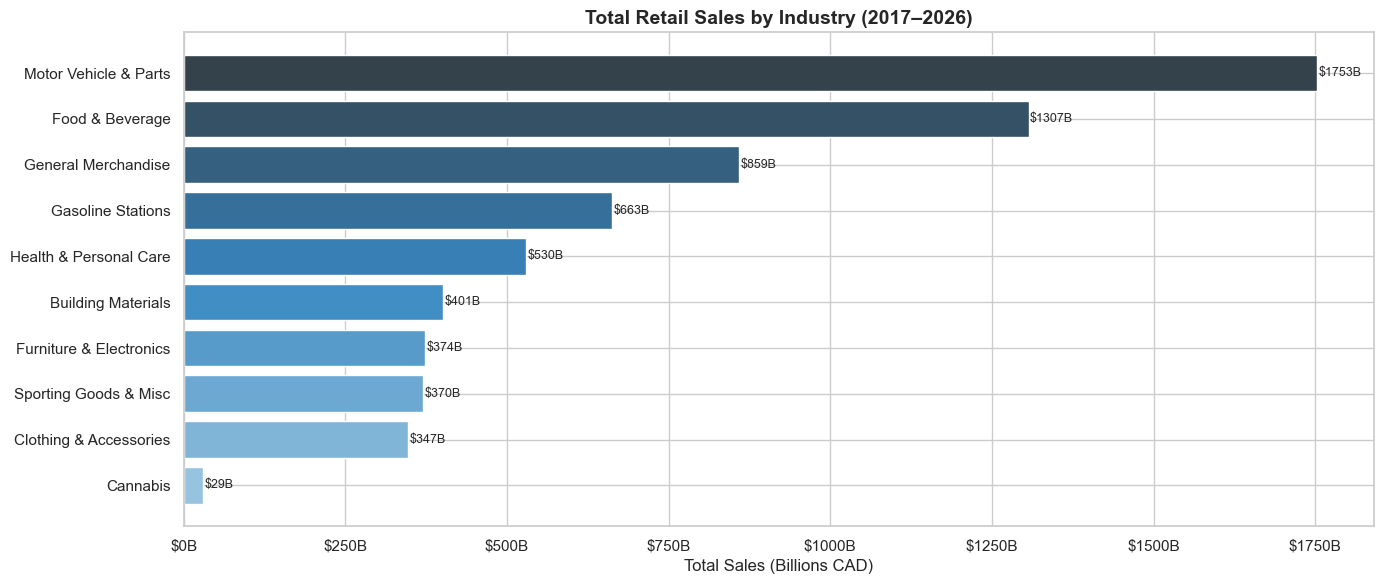

Top Industry: Motor Vehicle & Parts
Total Sales : $1753.3B


In [9]:
# ── KPI: Top Industry by Total Sales ─────────────────────────────────────────
industry_total = (industry_df
    .groupby('Industry')['Sales_Actual'].sum()
    .sort_values(ascending=False))

industry_total_disp = industry_total.copy()
industry_total_disp.index = [short_names.get(i, i) for i in industry_total_disp.index]

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('Blues_d', len(industry_total_disp))
bars = ax.barh(industry_total_disp.index[::-1], industry_total_disp.values[::-1]/1e9,
               color=palette, edgecolor='white')
ax.set_title('Total Retail Sales by Industry (2017–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales (Billions CAD)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}B'))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 2, bar.get_y() + bar.get_height()/2, f'${w:.0f}B', va='center', fontsize=9)
plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/03_top_industry_total_sales.png', dpi=150, bbox_inches='tight')
plt.show()

top_ind = industry_total.index[0]
print(f"Top Industry: {short_names.get(top_ind, top_ind)}")
print(f"Total Sales : ${industry_total.iloc[0]/1e9:.1f}B")

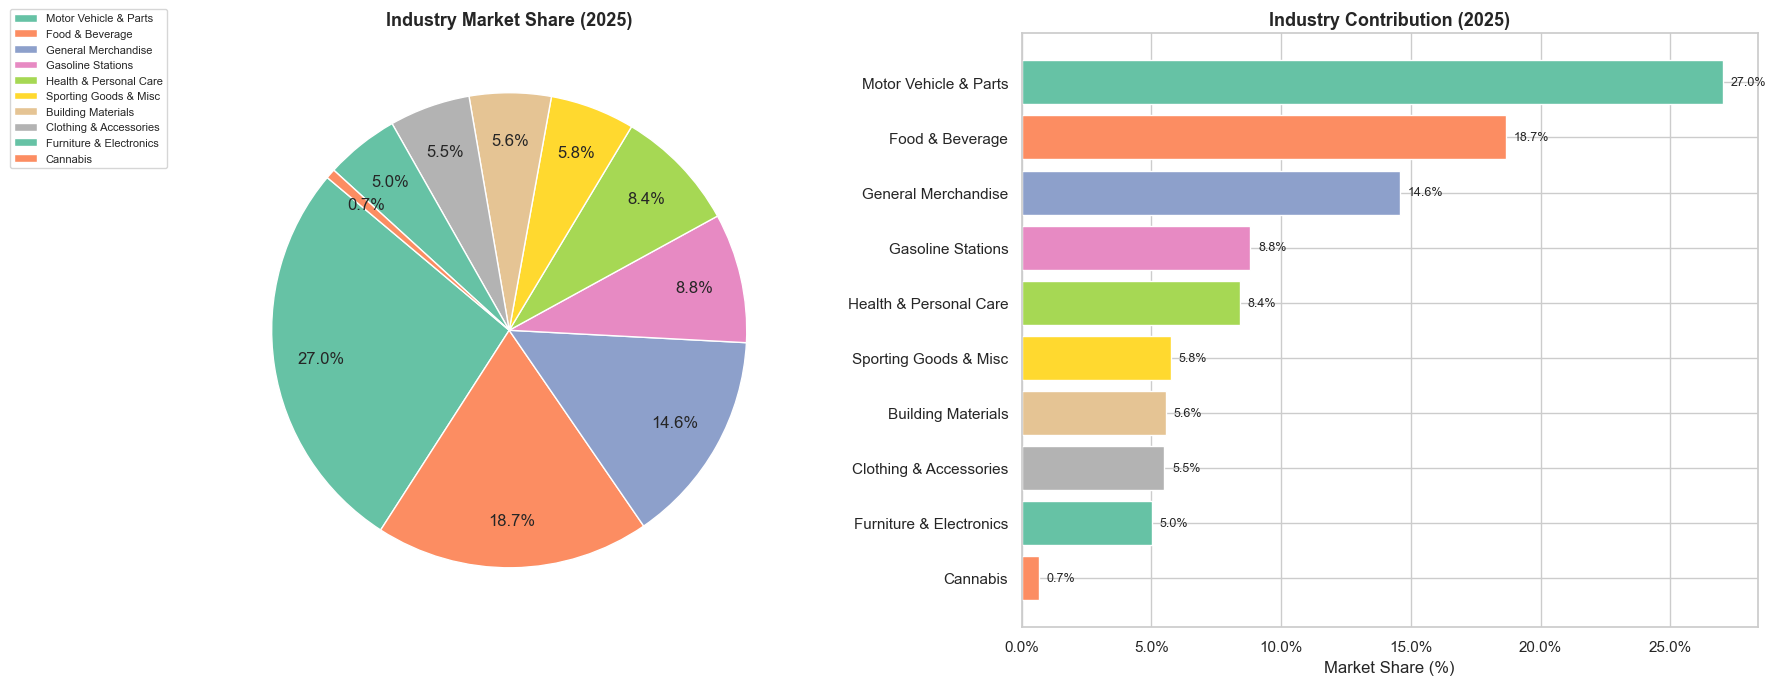

In [10]:
# ── KPI: Industry Market Share ────────────────────────────────────────────────
mkt = (industry_df[industry_df['Year'] == analysis_year]
       .groupby('Industry')['Sales_Actual'].sum())
mkt.index = [short_names.get(i, i) for i in mkt.index]
mkt_pct = (mkt / mkt.sum() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
palette = sns.color_palette('Set2', len(mkt_pct))

wedges, _, autotexts = axes[0].pie(
    mkt_pct.values, labels=None, autopct='%1.1f%%',
    startangle=140, colors=palette, pctdistance=0.8)
axes[0].set_title(f'Industry Market Share ({analysis_year})', fontsize=13, fontweight='bold')
axes[0].legend(mkt_pct.index, loc='upper left', bbox_to_anchor=(-0.35, 1.05), fontsize=8)

axes[1].barh(mkt_pct.index[::-1], mkt_pct.values[::-1], color=palette[::-1])
axes[1].set_title(f'Industry Contribution ({analysis_year})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Market Share (%)')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(mkt_pct.values[::-1]):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/04_industry_market_share.png', dpi=150, bbox_inches='tight')
plt.show()

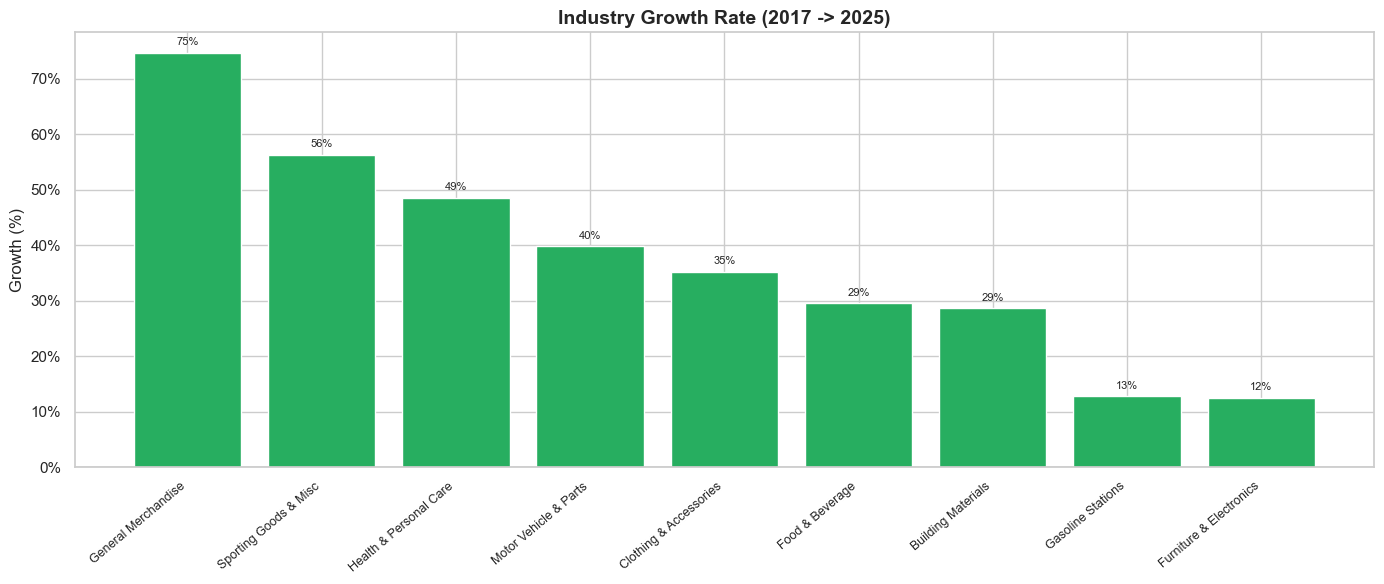

Fastest Growing: General Merchandise  (+74.6%)
Slowest Growing: Cannabis  (nan%)


In [11]:
# ── KPI: Industry Growth Rate ────────────────────────────────────────────────
pivot = (industry_df.groupby(['Year', 'Industry'])['Sales_Actual'].sum()
         .reset_index()
         .pivot(index='Year', columns='Industry', values='Sales_Actual'))
pivot.columns = [short_names.get(c, c) for c in pivot.columns]

industry_growth = (
    (pivot.loc[analysis_year] - pivot.loc[first_year]) / pivot.loc[first_year] * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#27ae60' if v >= 0 else '#c0392b' for v in industry_growth.values]
bars = ax.bar(industry_growth.index, industry_growth.values, color=colors, edgecolor='white')
ax.set_title(f'Industry Growth Rate ({first_year} -> {analysis_year})', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=40, ha='right', fontsize=9)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (1 if h >= 0 else -3),
            f'{h:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/05_industry_growth_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fastest Growing: {industry_growth.index[0]}  (+{industry_growth.iloc[0]:.1f}%)")
print(f"Slowest Growing: {industry_growth.index[-1]}  ({industry_growth.iloc[-1]:.1f}%)")

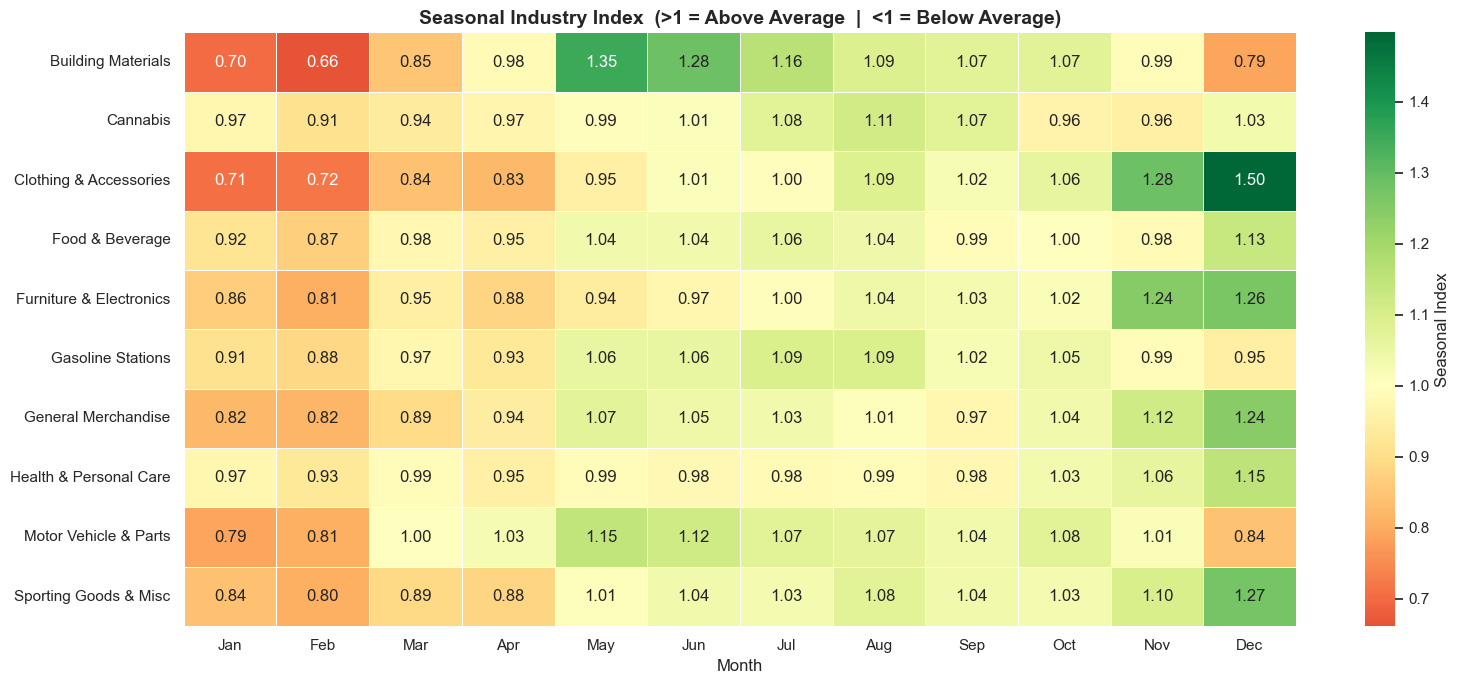

In [12]:
# ── KPI: Seasonal Industry Index (Heatmap) ───────────────────────────────────
monthly_ind = industry_df.groupby(['Industry', 'Month'])['Sales_Actual'].mean().reset_index()
annual_avg  = monthly_ind.groupby('Industry')['Sales_Actual'].mean().reset_index()
annual_avg.columns = ['Industry', 'Ann_Avg']
monthly_ind = monthly_ind.merge(annual_avg, on='Industry')
monthly_ind['Seasonal_Index'] = monthly_ind['Sales_Actual'] / monthly_ind['Ann_Avg']
monthly_ind['Industry_Short'] = monthly_ind['Industry'].map(short_names)

hm = monthly_ind.pivot(index='Industry_Short', columns='Month', values='Seasonal_Index')
hm.columns = month_labels

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(hm, annot=True, fmt='.2f', cmap='RdYlGn', center=1.0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Seasonal Index'})
ax.set_title('Seasonal Industry Index  (>1 = Above Average  |  <1 = Below Average)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('')
plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/06_seasonal_industry_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Geographic KPIs
**KPIs:** Top Province by Sales | Provincial Growth Rate | Province Contribution %

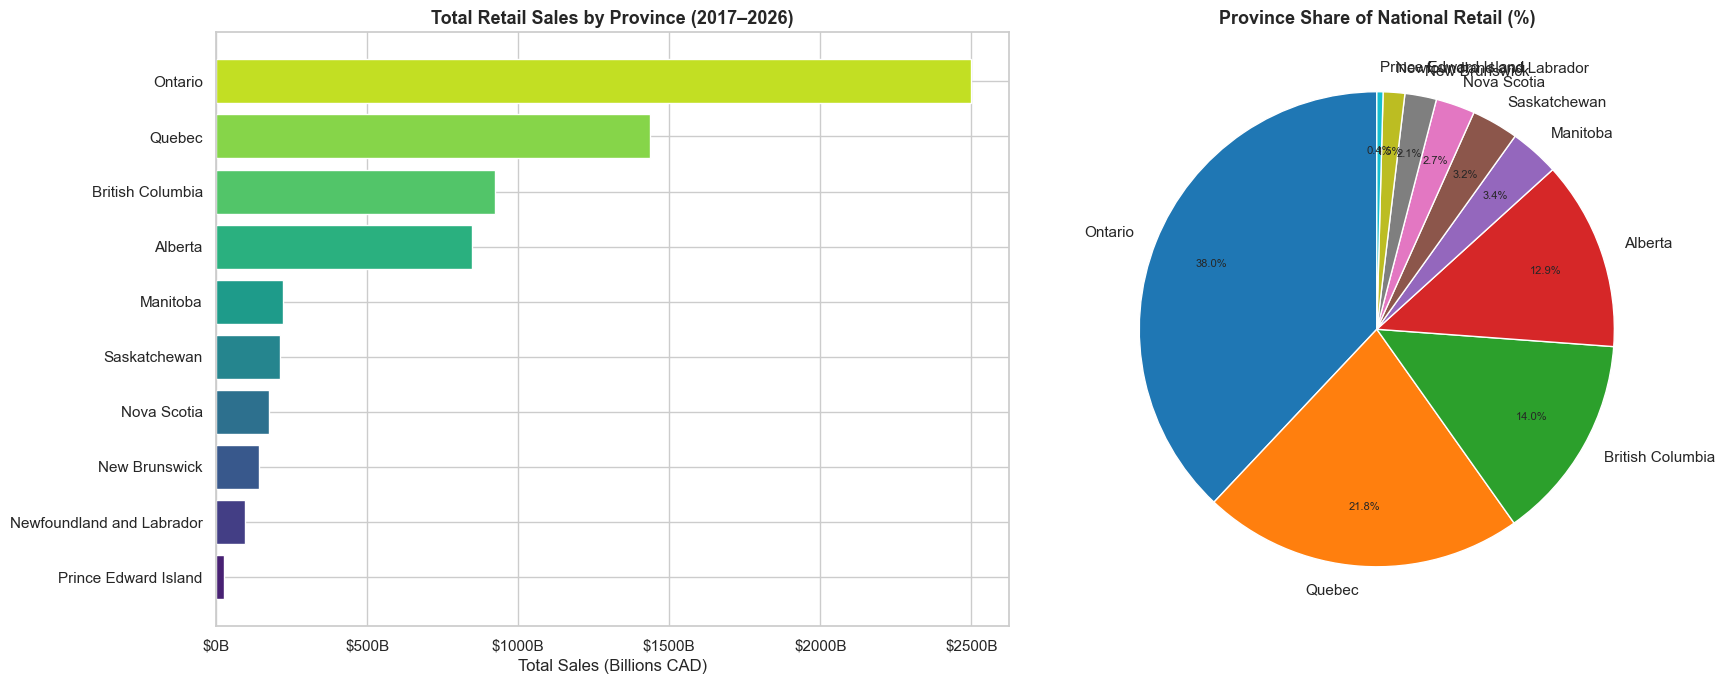

Top Province     : Ontario
Contribution     : 38.0%
Total Sales      : $2499.3B


In [13]:
# ── KPI: Top Province by Sales & Contribution ────────────────────────────────
prov_total  = province_df.groupby('GEO')['Sales_Actual'].sum().sort_values(ascending=False)
prov_contrib = (prov_total / prov_total.sum() * 100)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
palette = sns.color_palette('viridis', len(prov_total))

axes[0].barh(prov_total.index[::-1], prov_total.values[::-1]/1e9, color=palette)
axes[0].set_title('Total Retail Sales by Province (2017–2026)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Sales (Billions CAD)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}B'))

wedges, texts, autotexts = axes[1].pie(
    prov_contrib.values, labels=prov_contrib.index,
    autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette('tab10', len(prov_contrib)),
    pctdistance=0.75)
for t in autotexts: t.set_fontsize(8)
axes[1].set_title('Province Share of National Retail (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/07_province_sales_contribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top Province     : {prov_total.index[0]}")
print(f"Contribution     : {prov_contrib.iloc[0]:.1f}%")
print(f"Total Sales      : ${prov_total.iloc[0]/1e9:.1f}B")

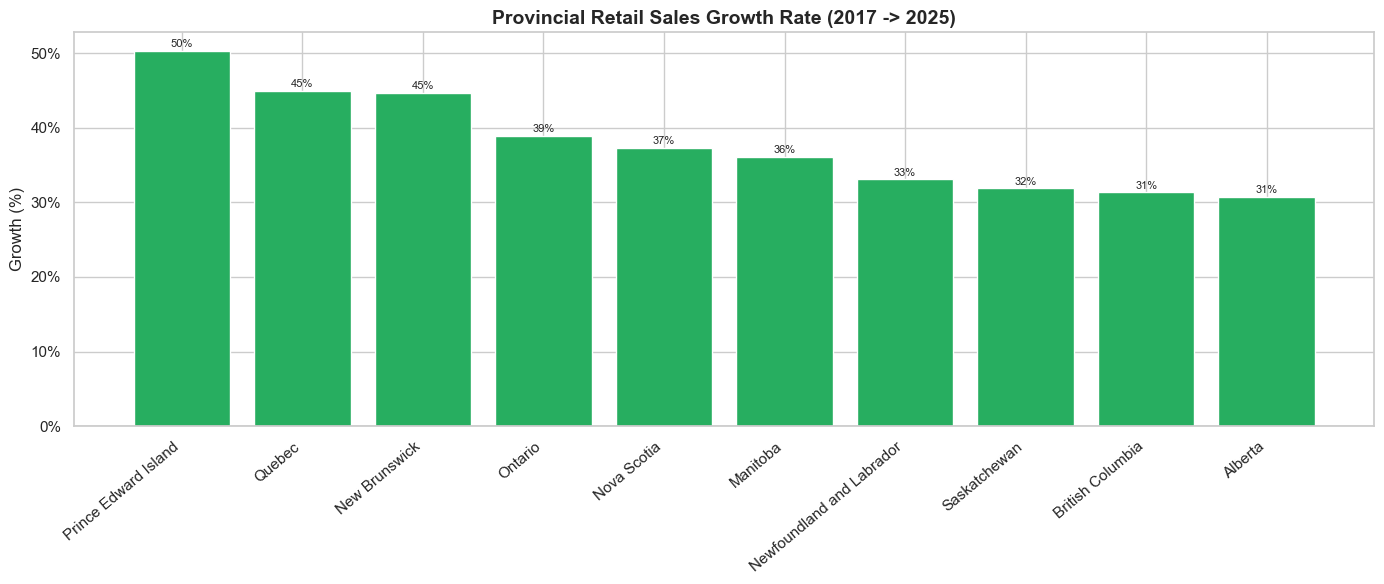

Fastest Growing Province: Prince Edward Island  (+50.3%)
Slowest Growing Province: Alberta  (30.8%)


In [14]:
# ── KPI: Provincial Growth Rate ──────────────────────────────────────────────
prov_yr = (province_df.groupby(['Year', 'GEO'])['Sales_Actual'].sum()
           .reset_index()
           .pivot(index='Year', columns='GEO', values='Sales_Actual'))

prov_growth = (
    (prov_yr.loc[analysis_year] - prov_yr.loc[first_year]) / prov_yr.loc[first_year] * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#27ae60' if v >= 0 else '#c0392b' for v in prov_growth.values]
ax.bar(prov_growth.index, prov_growth.values, color=colors, edgecolor='white')
ax.set_title(f'Provincial Retail Sales Growth Rate ({first_year} -> {analysis_year})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Growth (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=40, ha='right')
for i, (prov, val) in enumerate(prov_growth.items()):
    ax.text(i, val + (0.5 if val >= 0 else -1.5), f'{val:.0f}%',
            ha='center', fontsize=8)
plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/08_provincial_growth_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fastest Growing Province: {prov_growth.index[0]}  (+{prov_growth.iloc[0]:.1f}%)")
print(f"Slowest Growing Province: {prov_growth.index[-1]}  ({prov_growth.iloc[-1]:.1f}%)")

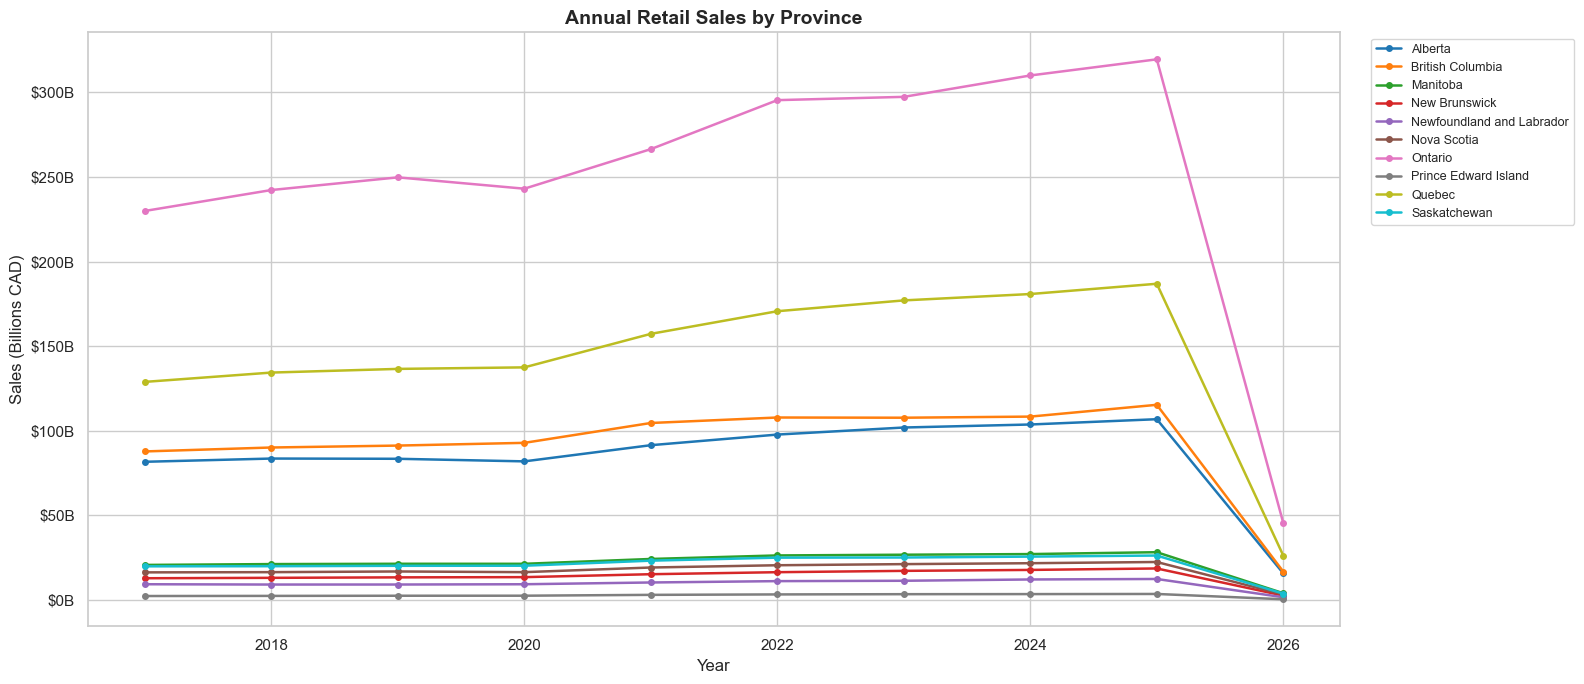

In [15]:
# ── Provincial Sales Trend Over Time ─────────────────────────────────────────
prov_trend = (province_df.groupby(['Year', 'GEO'])['Sales_Actual'].sum()
              .reset_index())

fig, ax = plt.subplots(figsize=(16, 7))
palette = sns.color_palette('tab10', prov_trend['GEO'].nunique())
for i, (prov, grp) in enumerate(prov_trend.groupby('GEO')):
    ax.plot(grp['Year'], grp['Sales_Actual']/1e9, marker='o', markersize=4,
            label=prov, color=palette[i], linewidth=1.8)
ax.set_title('Annual Retail Sales by Province', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Sales (Billions CAD)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/09_provincial_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — E-Commerce KPIs
**KPIs:** E-Commerce Sales Share | E-Commerce Growth Rate | Digital Adoption Rate

In [16]:
# ── KPI: E-Commerce Share & Growth ──────────────────────────────────────────
ecomm_df = ecomm_df.copy()
total_monthly = national_unadj.set_index('REF_DATE')['Sales_Actual']
ecomm_df['Total_Retail']      = ecomm_df['REF_DATE'].map(total_monthly)
ecomm_df['Ecomm_Share_pct']   = ecomm_df['Sales_Actual'] / ecomm_df['Total_Retail'] * 100
ecomm_df['YoY_Growth_pct']    = ecomm_df['Sales_Actual'].pct_change(12) * 100

print(f"E-Commerce Share — Start : {ecomm_df['Ecomm_Share_pct'].iloc[0]:.2f}%")
print(f"E-Commerce Share — End   : {ecomm_df['Ecomm_Share_pct'].iloc[-1]:.2f}%")
start_share = ecomm_df['Ecomm_Share_pct'].iloc[0]
end_share   = ecomm_df['Ecomm_Share_pct'].dropna().iloc[-1]
print(f"Digital Adoption Rate    : +{end_share - start_share:.2f} percentage points")

E-Commerce Share — Start : 2.68%
E-Commerce Share — End   : 6.83%
Digital Adoption Rate    : +4.15 percentage points


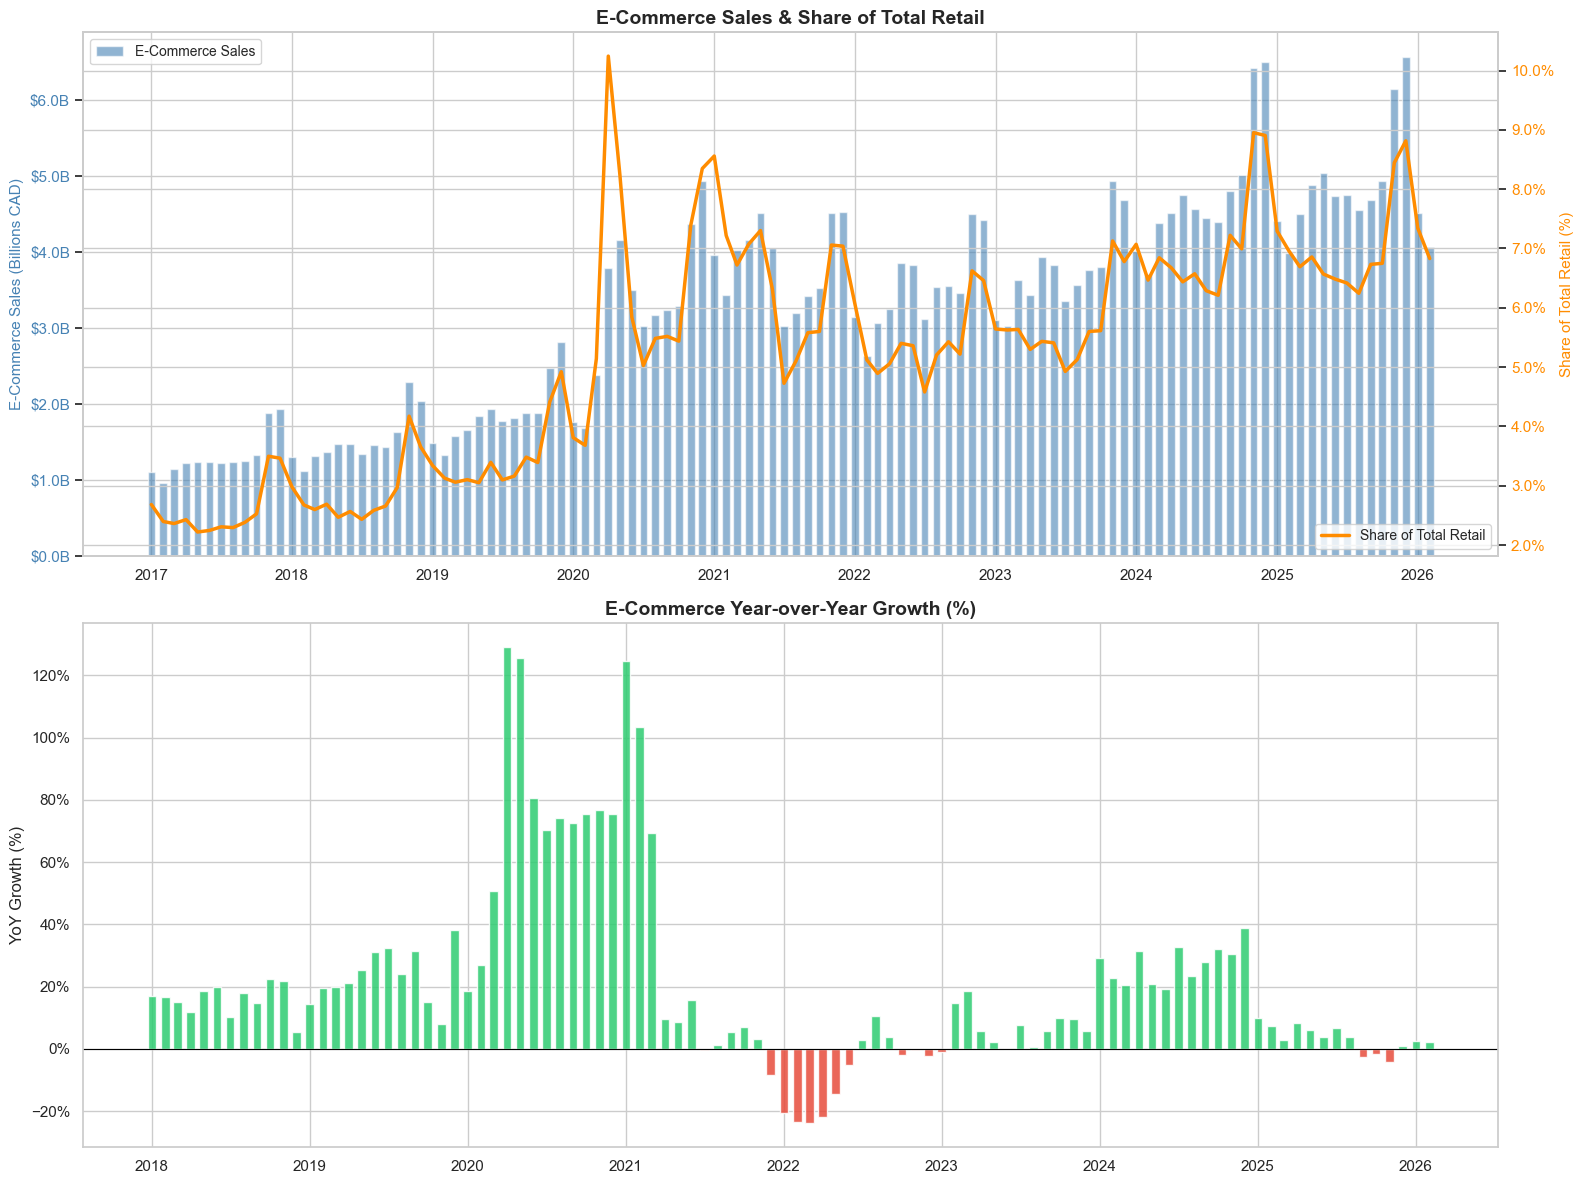


E-Commerce Average YoY Growth : 20.9%
Total Retail Average YoY      : 4.4%
E-commerce growing faster?    : YES


In [24]:
# ── E-Commerce Sales + Share Chart ───────────────────────────────────────────
# Dual-axis chart: bars = e-commerce sales (left axis), line = share % (right axis).
# Legends placed separately to avoid overlap; axis tick labels colour-coded.
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
ax1 = axes[0]
ax2 = ax1.twinx()

bars = ax1.bar(ecomm_df['REF_DATE'], ecomm_df['Sales_Actual']/1e9,
               color='steelblue', alpha=0.6, label='E-Commerce Sales (LHS)',
               width=20)
line, = ax2.plot(ecomm_df['REF_DATE'], ecomm_df['Ecomm_Share_pct'],
                 color='darkorange', linewidth=2.5, label='Share of Total Retail (RHS)')

ax1.set_title('E-Commerce Sales & Share of Total Retail', fontsize=14, fontweight='bold')
ax1.set_ylabel('E-Commerce Sales (Billions CAD)', color='steelblue', fontsize=11)
ax2.set_ylabel('Share of Total Retail (%)', color='darkorange', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.1f}B'))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(handles=[bars], labels=['E-Commerce Sales'], loc='upper left', fontsize=10)
ax2.legend(handles=[line], labels=['Share of Total Retail'], loc='lower right', fontsize=10)

# ── Bottom panel: YoY growth bars — width=20 days makes bars visible on date axis
ax = axes[1]
dates  = mdates.date2num(ecomm_df['REF_DATE'])
values = ecomm_df['YoY_Growth_pct'].values
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in values]
ax.bar(dates, values, width=20, color=colors, alpha=0.85)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('E-Commerce Year-over-Year Growth (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('YoY Growth (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/10_ecommerce_sales_share.png', dpi=150, bbox_inches='tight')
plt.show()

ecomm_avg_yoy = ecomm_df['YoY_Growth_pct'].mean()
retail_avg_yoy = avg_yoy
print(f"\nE-Commerce Average YoY Growth : {ecomm_avg_yoy:.1f}%")
print(f"Total Retail Average YoY      : {retail_avg_yoy:.1f}%")
print(f"E-commerce growing faster?    : {'YES' if ecomm_avg_yoy > retail_avg_yoy else 'NO'}")

---
## Section 5 — Seasonal KPIs
**KPIs:** Seasonal Impact Difference (Adj vs Unadj) | Holiday Sales Spike | Seasonal Stability Score

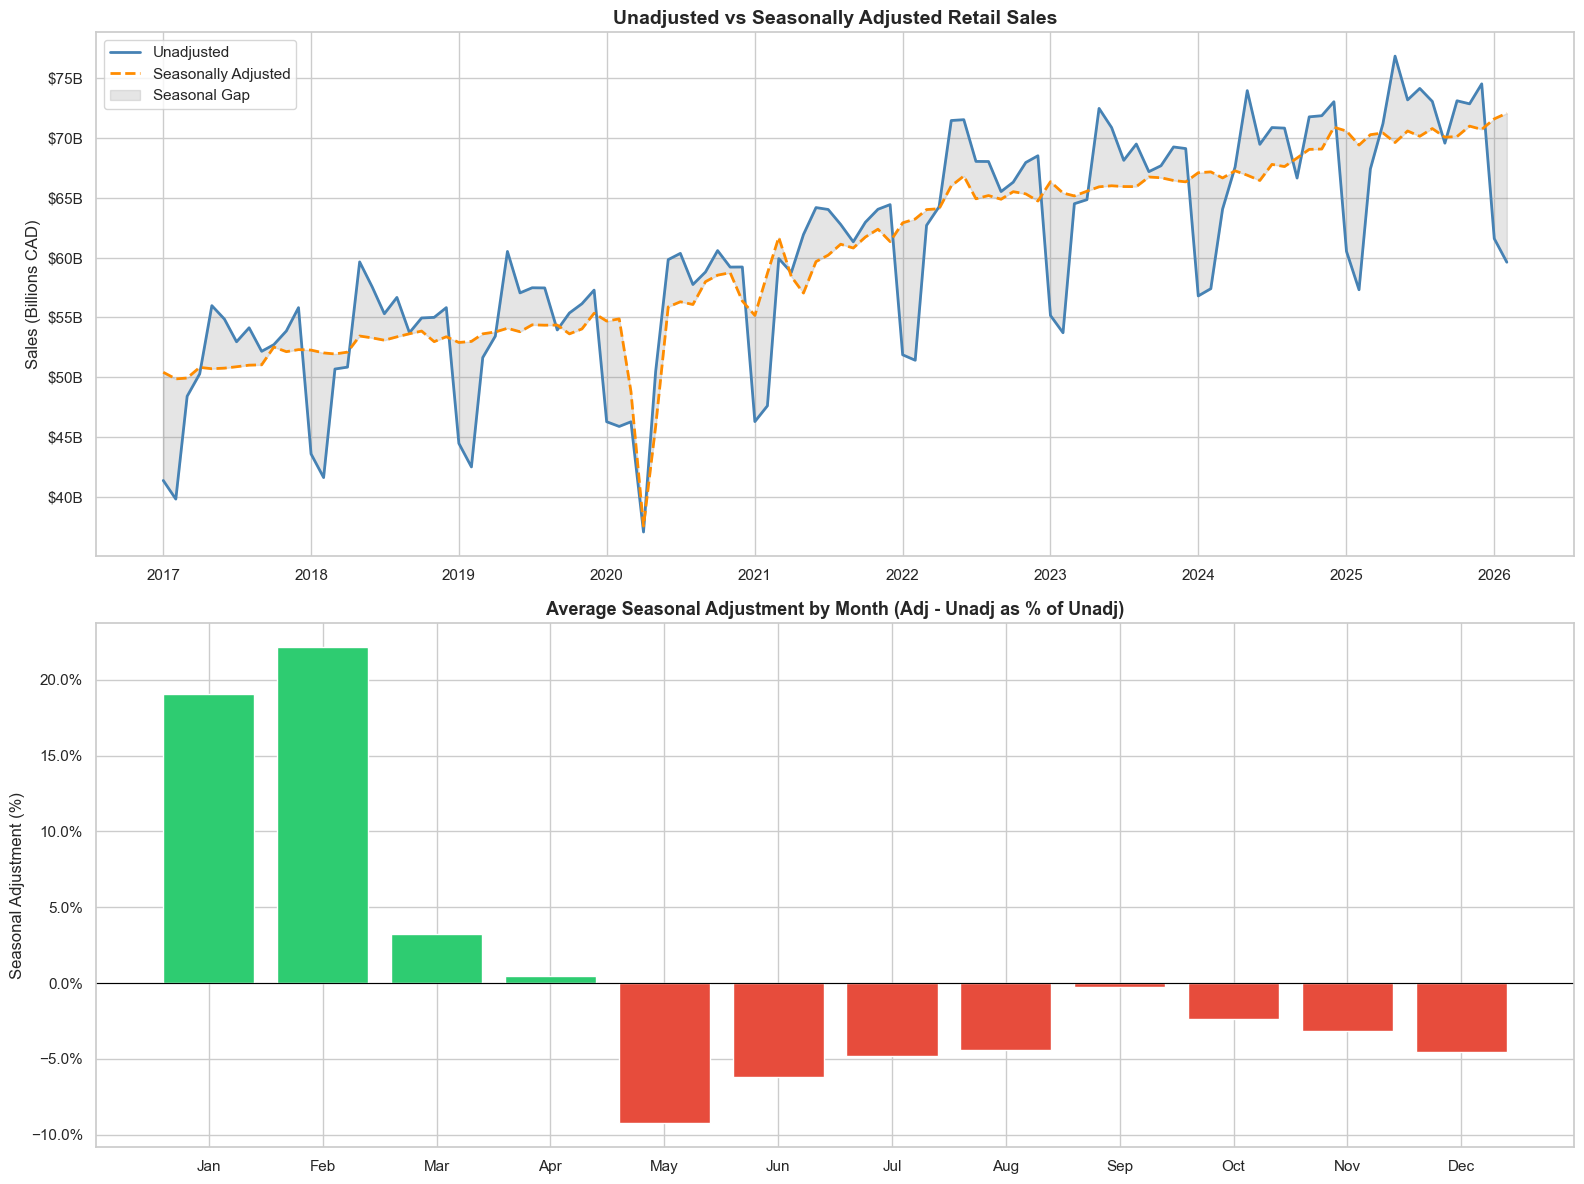

In [25]:
# ── KPI: Adjusted vs Unadjusted (Seasonal Impact) ────────────────────────────
merged = pd.merge(
    national_unadj[['REF_DATE','Year','Month','Month_Name','Sales_Actual']]
        .rename(columns={'Sales_Actual': 'Unadjusted'}),
    national_sadj[['REF_DATE','Sales_Actual']]
        .rename(columns={'Sales_Actual': 'Seasonally_Adjusted'}),
    on='REF_DATE'
)
merged['Seasonal_Gap']     = merged['Seasonally_Adjusted'] - merged['Unadjusted']
merged['Seasonal_Gap_pct'] = merged['Seasonal_Gap'] / merged['Unadjusted'] * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

axes[0].plot(merged['REF_DATE'], merged['Unadjusted']/1e9,
             label='Unadjusted', color='steelblue', linewidth=2)
axes[0].plot(merged['REF_DATE'], merged['Seasonally_Adjusted']/1e9,
             label='Seasonally Adjusted', color='darkorange', linewidth=2, linestyle='--')
axes[0].fill_between(merged['REF_DATE'],
                     merged['Unadjusted']/1e9, merged['Seasonally_Adjusted']/1e9,
                     alpha=0.2, color='gray', label='Seasonal Gap')
axes[0].set_title('Unadjusted vs Seasonally Adjusted Retail Sales', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales (Billions CAD)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}B'))
axes[0].legend()

monthly_gap = merged.groupby('Month')['Seasonal_Gap_pct'].mean()
axes[1].bar(month_labels, monthly_gap.values,
            color=['#e74c3c' if v < 0 else '#2ecc71' for v in monthly_gap.values])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Average Seasonal Adjustment by Month (Adj - Unadj as % of Unadj)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Seasonal Adjustment (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/11_adjusted_vs_unadjusted.png', dpi=150, bbox_inches='tight')
plt.show()

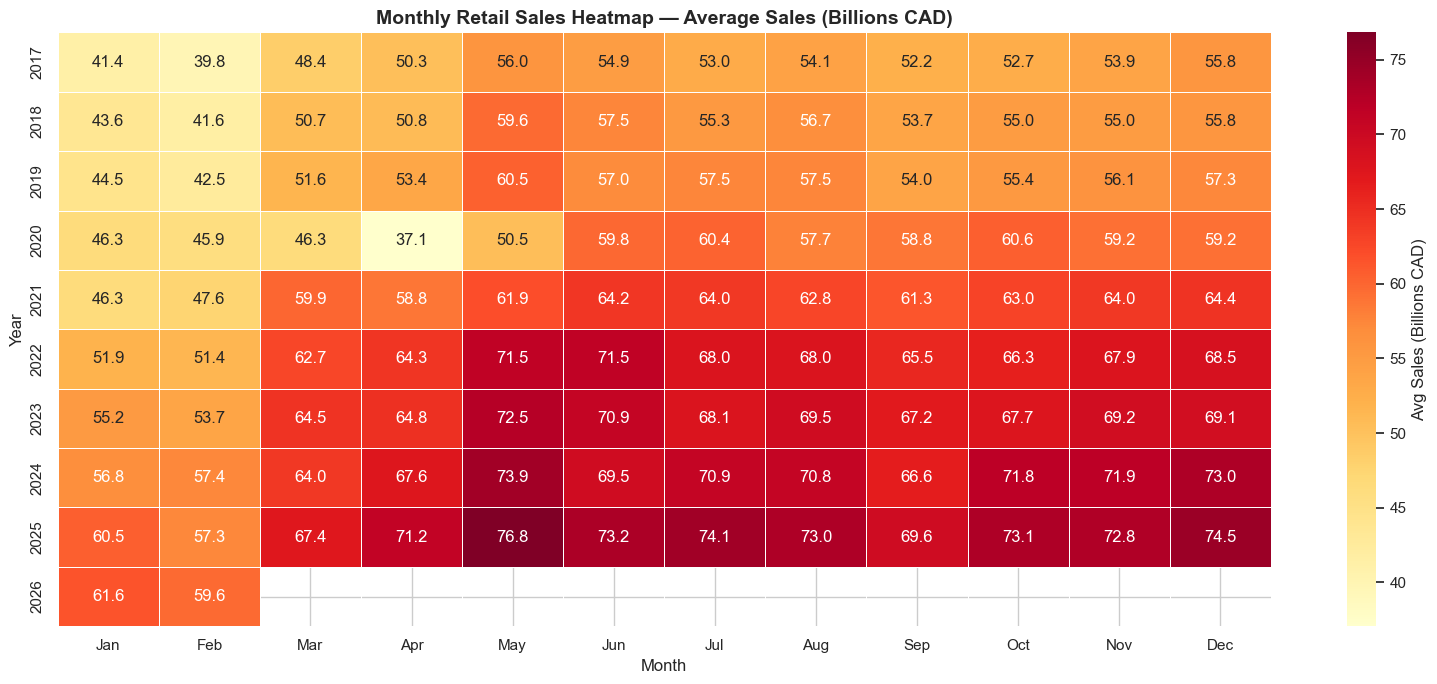

In [26]:
# ── Monthly Sales Heatmap ────────────────────────────────────────────────────
hm_pivot = national_unadj.pivot_table(
    index='Year', columns='Month', values='Sales_Actual', aggfunc='mean')
hm_pivot.columns = month_labels

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(hm_pivot/1e9, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Sales (Billions CAD)'})
ax.set_title('Monthly Retail Sales Heatmap — Average Sales (Billions CAD)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/12_monthly_sales_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

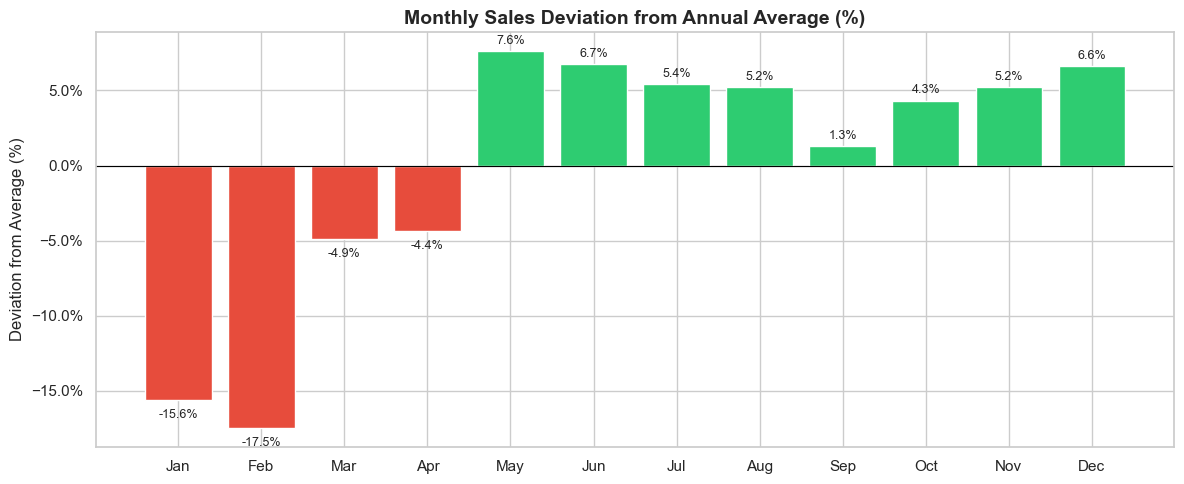

HOLIDAY SALES SPIKE ANALYSIS
Overall Average Monthly Sales: $60.22B
November Avg:  $63.35B  (+5.2% vs average)
December Avg:  $64.19B  (+6.6% vs average)


In [27]:
# ── KPI: Holiday Sales Spike ─────────────────────────────────────────────────
monthly_avg_sales = national_unadj.groupby('Month')['Sales_Actual'].mean()
overall_avg       = monthly_avg_sales.mean()
spikes = ((monthly_avg_sales - overall_avg) / overall_avg * 100)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in spikes.values]
ax.bar(month_labels, spikes.values, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Sales Deviation from Annual Average (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Deviation from Average (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(spikes.values):
    ax.text(i, v + (0.5 if v >= 0 else -1.2), f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/13_holiday_sales_spike.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("HOLIDAY SALES SPIKE ANALYSIS")
print("=" * 50)
print(f"Overall Average Monthly Sales: ${overall_avg/1e9:.2f}B")
for m_num, m_name in [(11,'November'), (12,'December')]:
    spike = spikes[m_num]
    print(f"{m_name} Avg:  ${monthly_avg_sales[m_num]/1e9:.2f}B  ({spike:+.1f}% vs average)")

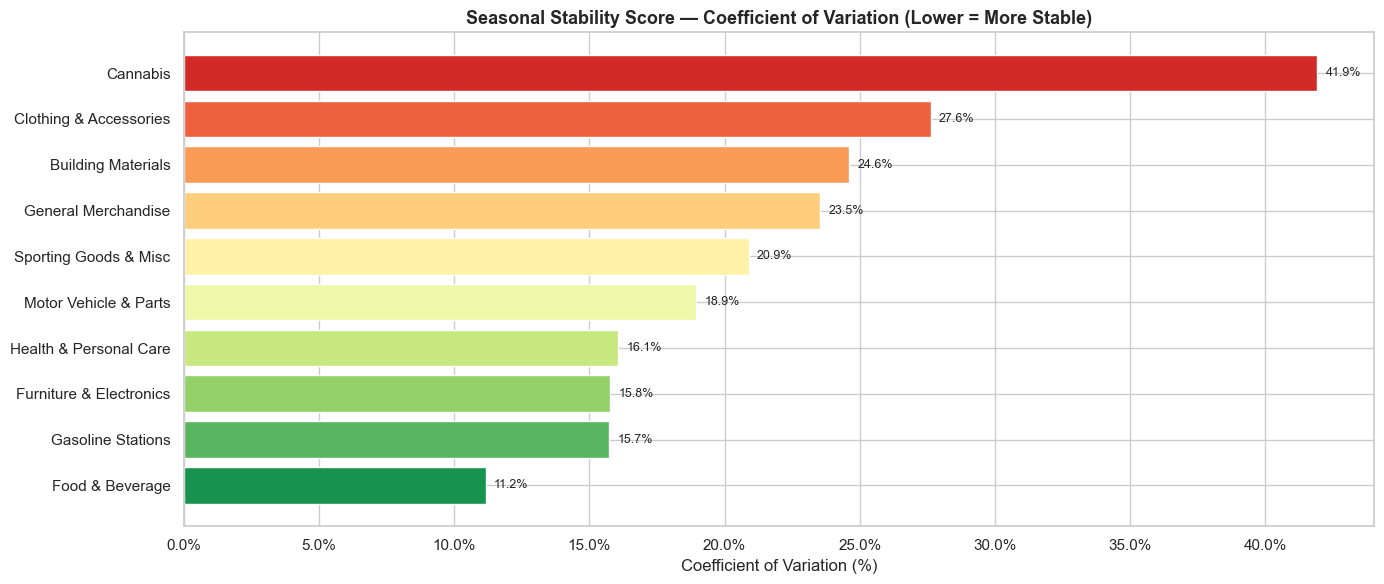

Most Stable Industry  : Food & Beverage  (CV 11.2%)
Most Volatile Industry: Cannabis  (CV 41.9%)


In [28]:
# ── KPI: Seasonal Stability Score (Coefficient of Variation) ─────────────────
ind_cv = industry_df.groupby('Industry')['Sales_Actual'].agg(['mean','std'])
ind_cv['CV_pct'] = ind_cv['std'] / ind_cv['mean'] * 100
ind_cv.index = [short_names.get(i, i) for i in ind_cv.index]
ind_cv = ind_cv.sort_values('CV_pct')

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('RdYlGn_r', len(ind_cv))
ax.barh(ind_cv.index, ind_cv['CV_pct'], color=palette, edgecolor='white')
ax.set_title('Seasonal Stability Score — Coefficient of Variation (Lower = More Stable)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient of Variation (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(ind_cv['CV_pct']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/14_seasonal_stability_score.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Most Stable Industry  : {ind_cv.index[0]}  (CV {ind_cv['CV_pct'].iloc[0]:.1f}%)")
print(f"Most Volatile Industry: {ind_cv.index[-1]}  (CV {ind_cv['CV_pct'].iloc[-1]:.1f}%)")

---
## Section 6 — Forecasting KPIs
**KPIs:** Forecast Accuracy (MAPE) | Predicted Future Sales | Trend Direction

**Model:** Holt-Winters Triple Exponential Smoothing (handles trend + seasonality)

In [29]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_percentage_error

# Build monthly time series
ts = national_unadj.set_index('REF_DATE')['Sales_Actual'].copy()
ts.index = pd.DatetimeIndex(ts.index).to_period('M').to_timestamp('M')
ts = ts.sort_index()

# Train / test split — hold out last 12 months for validation
train = ts.iloc[:-12]
test  = ts.iloc[-12:]

print(f"Training : {train.index[0].strftime('%b %Y')} -> {train.index[-1].strftime('%b %Y')}  ({len(train)} months)")
print(f"Test     : {test.index[0].strftime('%b %Y')}  -> {test.index[-1].strftime('%b %Y')}  ({len(test)} months)")

Training : Jan 2017 -> Feb 2025  (98 months)
Test     : Mar 2025  -> Feb 2026  (12 months)


In [30]:
# Fit Holt-Winters model
hw_model  = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
hw_fitted = hw_model.fit(optimized=True, use_brute=True)

# Forecast: 12 test months + 12 future months
n_ahead      = 24
forecast_raw = hw_fitted.forecast(n_ahead)
forecast_idx = pd.date_range(start=train.index[-1] + pd.offsets.MonthEnd(1),
                              periods=n_ahead, freq='ME')
forecast_all = pd.Series(forecast_raw.values, index=forecast_idx)

test_pred      = forecast_all.iloc[:12]
future_forecast = forecast_all.iloc[12:]

# Accuracy
mape = mean_absolute_percentage_error(test.values, test_pred.values) * 100
mae  = np.mean(np.abs(test.values - test_pred.values)) / 1e9

# Trend direction
trend_dir = 'INCREASING' if future_forecast.iloc[-1] > future_forecast.iloc[0] else 'DECREASING'
trend_pct = (future_forecast.iloc[-1] - future_forecast.iloc[0]) / future_forecast.iloc[0] * 100

print("=" * 50)
print("FORECASTING KPIs")
print("=" * 50)
print(f"Model             : Holt-Winters (Triple Exponential Smoothing)")
print(f"Forecast Accuracy : MAPE = {mape:.2f}%  (lower is better)")
print(f"Mean Abs Error    : ${mae:.2f}B per month")
print(f"Trend Direction   : {trend_dir}  ({trend_pct:+.1f}% over next 12 months)")

FORECASTING KPIs
Model             : Holt-Winters (Triple Exponential Smoothing)
Forecast Accuracy : MAPE = 3.79%  (lower is better)
Mean Abs Error    : $2.70B per month
Trend Direction   : DECREASING  (-10.5% over next 12 months)


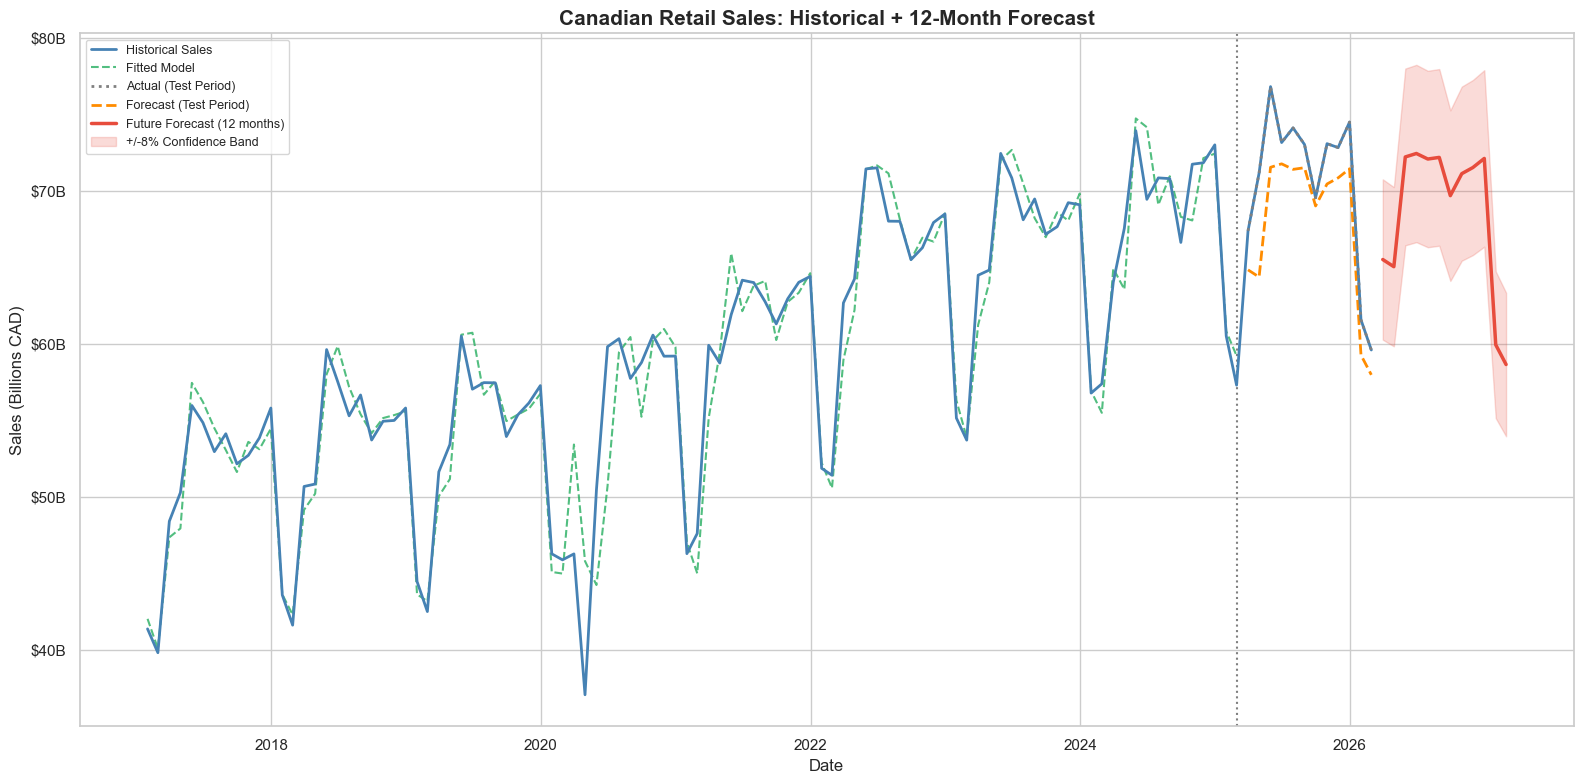

In [31]:
# Forecast visualization
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(ts.index, ts.values/1e9, color='steelblue', linewidth=2,
        label='Historical Sales', zorder=3)
ax.plot(train.index, hw_fitted.fittedvalues/1e9, color='#27ae60',
        linewidth=1.5, linestyle='--', alpha=0.8, label='Fitted Model')
ax.plot(test.index, test.values/1e9, color='gray', linewidth=2,
        linestyle=':', label='Actual (Test Period)', zorder=4)
ax.plot(test_pred.index, test_pred.values/1e9, color='darkorange',
        linewidth=2, linestyle='--', label='Forecast (Test Period)')
ax.plot(future_forecast.index, future_forecast.values/1e9, color='#e74c3c',
        linewidth=2.5, label='Future Forecast (12 months)', zorder=5)
ax.fill_between(future_forecast.index,
                future_forecast.values/1e9 * 0.92,
                future_forecast.values/1e9 * 1.08,
                alpha=0.2, color='#e74c3c', label='+/-8% Confidence Band')

ax.axvline(x=train.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Canadian Retail Sales: Historical + 12-Month Forecast',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (Billions CAD)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
os.makedirs('visualizations_images', exist_ok=True)
plt.savefig('visualizations_images/15_forecast_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Forward 12-month forecast table
print("FORWARD 12-MONTH SALES FORECAST")
print("-" * 40)
fmt = pd.DataFrame({
    'Month'   : future_forecast.index.strftime('%B %Y'),
    'Forecast': [f'${v/1e9:.2f}B' for v in future_forecast.values]
})
print(fmt.to_string(index=False))

FORWARD 12-MONTH SALES FORECAST
----------------------------------------
         Month Forecast
    March 2026  $65.53B
    April 2026  $65.06B
      May 2026  $72.23B
     June 2026  $72.46B
     July 2026  $72.10B
   August 2026  $72.20B
September 2026  $69.70B
  October 2026  $71.14B
 November 2026  $71.54B
 December 2026  $72.14B
  January 2027  $59.95B
 February 2027  $58.66B


---
## Section 7 — Analytical Questions & Answers
Consolidated answers to all questions from the Business Goals document.

In [33]:
print("=" * 70)
print("ANALYTICAL QUESTIONS — ANSWERS")
print("=" * 70)

print("\n--- SALES ANALYSIS ---")
print(f"Q: Which industry generates the highest retail sales?")
print(f"A: {short_names.get(industry_total.index[0], industry_total.index[0])}"
      f"  (${industry_total.iloc[0]/1e9:.1f}B total)")

print(f"\nQ: Which province contributes most to retail revenue?")
print(f"A: {prov_total.index[0]}  ({prov_contrib.iloc[0]:.1f}% of provincial retail)")

print(f"\nQ: How do sales change monthly?")
print(f"A: Average MoM change {avg_mom:.2f}%  |  Std dev {national_unadj['MoM_Growth_pct'].std():.1f}%")

print("\n--- SEASONAL QUESTIONS ---")
print(f"Q: Which industries are highly seasonal?")
print(f"A: Most volatile -> {ind_cv.index[-1]}  (CV {ind_cv['CV_pct'].iloc[-1]:.1f}%)")
print(f"   Most stable   -> {ind_cv.index[0]}   (CV {ind_cv['CV_pct'].iloc[0]:.1f}%)")

print(f"\nQ: How much difference between adjusted and unadjusted sales?")
avg_gap = merged['Seasonal_Gap_pct'].abs().mean()
print(f"A: Average absolute seasonal adjustment: {avg_gap:.1f}% of unadjusted value")

print("\n--- E-COMMERCE QUESTIONS ---")
print(f"Q: Is e-commerce growing faster than traditional retail?")
print(f"A: E-commerce avg YoY: {ecomm_avg_yoy:.1f}%  |  Total retail avg YoY: {avg_yoy:.1f}%")
print(f"   E-commerce growing faster: {'YES' if ecomm_avg_yoy > avg_yoy else 'NO'}")

print(f"\nQ: E-commerce adoption rate change?")
print(f"A: {start_share:.2f}% -> {end_share:.2f}%  (+{end_share - start_share:.2f} ppts)")

print("\n--- GEOGRAPHIC QUESTIONS ---")
print(f"Q: Which regions show fastest retail growth?")
print(f"A: {prov_growth.index[0]}  (+{prov_growth.iloc[0]:.1f}%)")

print(f"\nQ: Which provinces are underperforming?")
for p, g in prov_growth.tail(3).items():
    print(f"   {p}: {g:+.1f}%")

print("\n--- FORECASTING QUESTIONS ---")
print(f"Q: What will future retail sales look like?")
print(f"A: {trend_dir}  by {trend_pct:+.1f}% over next 12 months")
print(f"   Model accuracy (MAPE): {mape:.2f}%")

print(f"\nQ: Which sectors are expected to grow?")
growing = industry_growth[industry_growth > 0]
for ind_name, rate in growing.items():
    print(f"   {ind_name}: +{rate:.1f}% (historical growth)")

ANALYTICAL QUESTIONS — ANSWERS

--- SALES ANALYSIS ---
Q: Which industry generates the highest retail sales?
A: Motor Vehicle & Parts  ($1753.3B total)

Q: Which province contributes most to retail revenue?
A: Ontario  (38.0% of provincial retail)

Q: How do sales change monthly?
A: Average MoM change 0.82%  |  Std dev 9.9%

--- SEASONAL QUESTIONS ---
Q: Which industries are highly seasonal?
A: Most volatile -> Cannabis  (CV 41.9%)
   Most stable   -> Food & Beverage   (CV 11.2%)

Q: How much difference between adjusted and unadjusted sales?
A: Average absolute seasonal adjustment: 7.0% of unadjusted value

--- E-COMMERCE QUESTIONS ---
Q: Is e-commerce growing faster than traditional retail?
A: E-commerce avg YoY: 20.9%  |  Total retail avg YoY: 4.4%
   E-commerce growing faster: YES

Q: E-commerce adoption rate change?
A: 2.68% -> 6.83%  (+4.15 ppts)

--- GEOGRAPHIC QUESTIONS ---
Q: Which regions show fastest retail growth?
A: Prince Edward Island  (+50.3%)

Q: Which provinces are und

---
## Final KPI Summary Dashboard

In [34]:
print("=" * 70)
print("       CANADIAN RETAIL SALES — FULL KPI SUMMARY DASHBOARD")
print("=" * 70)

print("\nSALES KPIs")
print(f"  Total Retail Sales (All-Time)   : ${df['Sales_Actual'].sum()/1e12:.2f} Trillion CAD")
print(f"  Average Monthly Sales           : ${avg_monthly/1e9:.2f}B")
print(f"  Average MoM Growth              : {avg_mom:.2f}%")
print(f"  Average YoY Growth              : {avg_yoy:.2f}%")
print(f"  Maximum Sales Month             : {max_row['Month_Name']} {max_row['Year']}  (${max_row['Sales_Actual']/1e9:.2f}B)")
print(f"  Minimum Sales Month             : {min_row['Month_Name']} {min_row['Year']}  (${min_row['Sales_Actual']/1e9:.2f}B)")

print("\nINDUSTRY KPIs")
print(f"  Top Industry by Sales           : {short_names.get(industry_total.index[0], industry_total.index[0])}")
print(f"  Top Market Share ({analysis_year})        : {mkt_pct.iloc[0]:.1f}%  ({mkt_pct.index[0]})")
print(f"  Fastest Growing Industry        : {industry_growth.index[0]}  ({industry_growth.iloc[0]:+.1f}%)")
print(f"  Most Stable Industry            : {ind_cv.index[0]}  (CV {ind_cv['CV_pct'].iloc[0]:.1f}%)")
print(f"  Most Volatile Industry          : {ind_cv.index[-1]}  (CV {ind_cv['CV_pct'].iloc[-1]:.1f}%)")

print("\nGEOGRAPHIC KPIs")
print(f"  Top Province by Sales           : {prov_total.index[0]}")
print(f"  Province Contribution (%)       : {prov_contrib.iloc[0]:.1f}%")
print(f"  Fastest Growing Province        : {prov_growth.index[0]}  ({prov_growth.iloc[0]:+.1f}%)")
print(f"  Slowest Growing Province        : {prov_growth.index[-1]}  ({prov_growth.iloc[-1]:+.1f}%)")

print("\nE-COMMERCE KPIs")
print(f"  Initial E-Commerce Share        : {start_share:.2f}%")
print(f"  Latest E-Commerce Share         : {end_share:.2f}%")
print(f"  Digital Adoption Rate Increase  : +{end_share - start_share:.2f} percentage points")
print(f"  E-Commerce vs Total Retail YoY  : {ecomm_avg_yoy:.1f}% vs {avg_yoy:.1f}%")

print("\nSEASONAL KPIs")
print(f"  November Holiday Spike          : {spikes[11]:+.1f}% above annual average")
print(f"  December Holiday Spike          : {spikes[12]:+.1f}% above annual average")
print(f"  Avg Seasonal Adjustment Gap     : {avg_gap:.1f}% of unadjusted sales")

print("\nFORECASTING KPIs")
print(f"  Model                           : Holt-Winters Triple Exp. Smoothing")
print(f"  Forecast Accuracy (MAPE)        : {mape:.2f}%")
print(f"  Mean Absolute Error             : ${mae:.2f}B/month")
print(f"  12-Month Trend Direction        : {trend_dir}  ({trend_pct:+.1f}%)")
print("=" * 70)

       CANADIAN RETAIL SALES — FULL KPI SUMMARY DASHBOARD

SALES KPIs
  Total Retail Sales (All-Time)   : $79.71 Trillion CAD
  Average Monthly Sales           : $724.62B
  Average MoM Growth              : 0.61%
  Average YoY Growth              : 5.05%
  Maximum Sales Month             : May 2025  ($903.23B)
  Minimum Sales Month             : April 2020  ($448.49B)

INDUSTRY KPIs
  Top Industry by Sales           : Motor Vehicle & Parts
  Top Market Share (2025)        : 6.9%  (Automobile dealers)
  Fastest Growing Industry        : Miscellaneous retailers  (+95.4%)
  Most Stable Industry            : Supermarkets & Other Grocery  (CV 3.3%)
  Most Volatile Industry          : Jewellery, Luggage & Leather  (CV 24.8%)

GEOGRAPHIC KPIs
  Top Province by Sales           : Ontario
  Province Contribution (%)       : 38.0%
  Fastest Growing Province        : Prince Edward Island  (+53.7%)
  Slowest Growing Province        : Alberta  (+29.8%)

E-COMMERCE KPIs
  Initial E-Commerce Share    